In [1]:
from typing import Callable, List, Optional, Tuple, Union

import scanpy as sc
import scvelo as scv
import anndata
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.io import loadmat
import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

import networkx as nx
from scipy.sparse import csr_matrix

In [2]:
## 神经网络框架
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 128,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 128,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class LatentODE(nn.Module):
    def __init__(
        self,
        n_latent: int = 20,
        n_hidden: int = 32,
    ):
        super(LatentODE, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=n_latent, out_features=n_hidden, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_hidden, bias=True),
            nn.BatchNorm1d(n_hidden),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_latent, bias=True)
            )

    def forward(self, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        return output

In [3]:
## 加载训练好的模型
encoder = Encoder(n_int=1066)
decoder = Decoder(n_int=1066)
dynamics_learner = LatentODE()
dynamics_learner.load_state_dict(torch.load('Parameters_dynamics.pickle', map_location=torch.device('cpu')))
encoder.load_state_dict(torch.load('Parameters_encoder.pickle', map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load('Parameters_decoder.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()
encoder.eval()
decoder.eval()

Decoder(
  (fc1): Sequential(
    (L1): Linear(in_features=20, out_features=128, bias=True)
  )
  (fc2): Linear(in_features=128, out_features=1066, bias=True)
)

In [4]:
## 提取Decoder的参数
fc1_weight = decoder.fc1.L1.weight.data
fc1_bias = decoder.fc1.L1.bias.data
fc2_weight = decoder.fc2.weight.data
fc2_bias = decoder.fc2.bias.data

In [5]:
## Decoder的雅可比矩阵
weight = torch.matmul(fc2_weight, fc1_weight).numpy()
bias = (torch.matmul(fc2_weight, fc1_bias) + fc2_bias).numpy()

In [6]:
adata = sc.read("../adata_U2OS_DeepCycle.h5ad")
adata.var.index = adata.var['name']

In [7]:
bdata = sc.read("../adata_U2OS_DeepCycle.h5ad")
dyn.pp.recipe_monocle(bdata)
adata.obs['cell_cycle_phase'] = bdata.obs['cell_cycle_phase']
# 将theta的初始时刻平移至G1期初始
adata.obs['theta'] = adata.obs['theta'] - 0.27
adata.obs['theta'] = adata.obs['theta'].apply(lambda x: x + 1 if x < 0 else x)
adata

|-----> apply Monocole recipe to adata...
|-----> convert ensemble name to official gene name
|-----? Your adata object uses non-official gene names as gene index. 
Dynamo is converting those names to official gene names.


49 input query terms found no hit:	['ENSG00000112096', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000168078', 'ENSG00000170152', 'ENS


|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----> filtering cells...
|-----> 1040 cells passed basic filters.
|-----> filtering gene...
|-----> 10889 genes passed basic filters.
|-----> calculating size factor...
|-----> selecting genes in layer: X, sort method: SVR...
|-----> applying PCA ...
|-----> cell cycle scoring...
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [23.0883s]
|-----> [Cell Cycle Scores Estimation] completed [0.0591s]
|-----> [recipe_monocle preprocess] completed [15.5866s]


AnnData object with n_obs × n_vars = 1040 × 13450
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain', 'theta', 'cell_cycle_theta', 'cell_cycle_phase'
    var: 'name', 'biotype', 'description', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'GeneName', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'louvain', 'neighbors', 'pca', 'phase_colors', 'plate_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spanning', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [8]:
## 得到伪时间
percentiles = np.percentile(adata.obs['theta'], np.linspace(0, 100, 100))
indices = np.digitize(adata.obs['theta'], percentiles)
pseudotime = indices * 0.01
adata.obs['pseudotime'] = pseudotime

In [9]:
th=adata.obs['pseudotime']
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

In [10]:
cell_cycle_colors = {'G1-S': '#d70000',
                     'S': '#2f3ea8',
                     'G2-M': '#da96ff',
                     'M': '#ad94ec',
                     'M-G1': '#a76b9a',}
# 将细胞周期阶段映射到颜色
colors = adata.obs['cell_cycle_phase'].map(cell_cycle_colors)

In [11]:
list_of_genes_file = "../genes_1066.json"
expression_threshold = 5
with open(list_of_genes_file,'r') as fp:
    cell_cycle_genes = json.load(fp)

In [12]:
## 数据准备
def generate_input(list_of_genes, adata):
    gene_list = list(adata.var.index)
    n = gene_list.index(list_of_genes[0])
    df_all = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })

    for gene in list_of_genes[1:]:
        try:
            n = gene_list.index(gene)
            df = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })
            if (df.mean()<expression_threshold).all():
                list_of_genes.remove(gene)
                continue
        except ValueError:
            list_of_genes.remove(gene)
            continue
        df_all = pd.concat([df_all, df], axis=1)

    normalized_df=(df_all-df_all.mean())/df_all.std()
    np_data = normalized_df.to_numpy()
    nan_columns = list(np.where(np.any(~np.isfinite(np_data),axis=0))[0])
    nan_indexes = list([ n//2 for n in nan_columns])
    even_columns = list([ 2*n for n in nan_indexes ])
    odd_columns = list([ 2*n+1 for n in nan_indexes ])
    for idx in sorted(nan_indexes, reverse=True):
        del list_of_genes[idx]
    columns_to_drop = sorted(even_columns + odd_columns)
    normalized_df.columns = list(range(normalized_df.shape[1]))
    df_all.columns = list(range(df_all.shape[1]))
    df_all = df_all.drop(df_all.columns[columns_to_drop], axis=1)
    normalized_df = normalized_df.drop(normalized_df.columns[columns_to_drop], axis=1)
    #print("Left genes: ",len(list_of_genes), normalized_df.shape)
    
    return list_of_genes, normalized_df.to_numpy() #cells x (2 genes)

In [13]:
## 过滤数据
genes, np_data = generate_input(cell_cycle_genes, adata)
print("[Genes]:", genes)
print("[N. OF USED GENES]",len(genes))
n_genes = len(genes)
n_cells = np_data.shape[0]
n_columns = np_data.shape[1]
if n_columns != 2*n_genes:
    print("[ERROR]: incoherent number of genes and columns")

print( "[Total number of cells]:", n_cells)

[Genes]: ['AAAS', 'AATF', 'ABL1', 'ABRAXAS2', 'ACTB', 'ACTR1A', 'ACTR2', 'ACTR3', 'ACTR8', 'ACVR1', 'ADAM10', 'ADAMTS1', 'AHCTF1', 'AKAP8', 'AKAP9', 'AKT1', 'AKT2', 'ALKBH4', 'ALMS1', 'ANAPC1', 'ANAPC11', 'ANAPC13', 'ANAPC15', 'ANAPC16', 'ANAPC4', 'ANAPC5', 'ANAPC7', 'ANGEL2', 'ANKLE2', 'ANKRD17', 'ANLN', 'ANXA1', 'ANXA11', 'APBB1', 'APBB2', 'APC', 'APEX1', 'APEX2', 'APP', 'APPL1', 'APPL2', 'ARAP1', 'ARF1', 'ARF6', 'ARL3', 'ARL8B', 'ARNTL', 'ARPP19', 'ASPM', 'ATAD5', 'ATF2', 'ATP2B4', 'ATR', 'ATRX', 'AURKA', 'AURKAIP1', 'AURKB', 'AVPI1', 'AZI2', 'BABAM2', 'BACH1', 'BAG6', 'BANP', 'BAP1', 'BARD1', 'BAX', 'BBS4', 'BCAT1', 'BCCIP', 'BCL2', 'BCL2L1', 'BECN1', 'BEX2', 'BID', 'BIN1', 'BIN3', 'BIRC2', 'BIRC5', 'BIRC6', 'BLM', 'BMP4', 'BOD1', 'BOP1', 'BORA', 'BRCA1', 'BRCA2', 'BRD4', 'BRD7', 'BRIP1', 'BTG1', 'BTG2', 'BTG3', 'BTRC', 'BUB1', 'BUB1B', 'BUB3', 'C2CD3', 'C6orf89', 'CAB39', 'CACUL1', 'CALM1', 'CALM3', 'CALR', 'CAMK2N1', 'CASP2', 'CASP3', 'CAV2', 'CBX3', 'CBX5', 'CCAR1', 'CCAR2', 'CC

In [14]:
## 归一化细胞数据
np_data = np_data[:, ::2]

for i in range(np_data.shape[1]):
    gene_data = np_data[:, i]
    gene_data -= gene_data.min()
    gene_data /= gene_data.max()
    np_data[:, i] = gene_data
np_data.shape

(1040, 1066)

In [15]:
## 定义vf_func及jac_func
def vf_func(point: np.ndarray) -> np.ndarray:
    dim = point.shape[1]
    point = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    f = dynamics_learner(point)
    return f.detach().numpy()

def jac_func_dyn(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(dynamics_learner, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_encoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((20, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(encoder, x1)[0].squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_decoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((1066, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(decoder, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

In [16]:
## 计算重构及潜表示
# np_data = (np_data - np_data.min(0)) / (np_data.max(0) - np_data.min(0))
raw = torch.as_tensor(np_data, dtype=torch.float32)
latent, _ = encoder(raw)
mean = latent.mean(0).detach()
std = latent.std(0).detach()
latent_std = torch.exp(0.5 * encoder(raw)[1])
reconstruct = decoder(latent)

raw = raw.detach().numpy()
reconstruct = reconstruct.detach().numpy()
latent = latent.detach().numpy()
latent_std = latent_std.detach().numpy()

In [17]:
latent_std.mean(0)

array([0.01423306, 0.99998826, 0.9971218 , 0.9976258 , 0.9982652 ,
       0.99763596, 0.99695396, 0.99971724, 0.01039779, 0.9990738 ,
       0.01292057, 0.9985256 , 0.99838185, 0.00901267, 0.9987287 ,
       0.00797676, 0.99852246, 0.9972889 , 0.00807239, 0.01422244],
      dtype=float32)

In [18]:
## 对隐空间坐标标准化
latent_z = (latent - latent.mean(0))/latent.std(0)

In [19]:
new_weight = weight * latent.std(0)
new_bias = weight @ latent.mean(0) + bias
# (latent_z @ new_weight.T + new_bias)

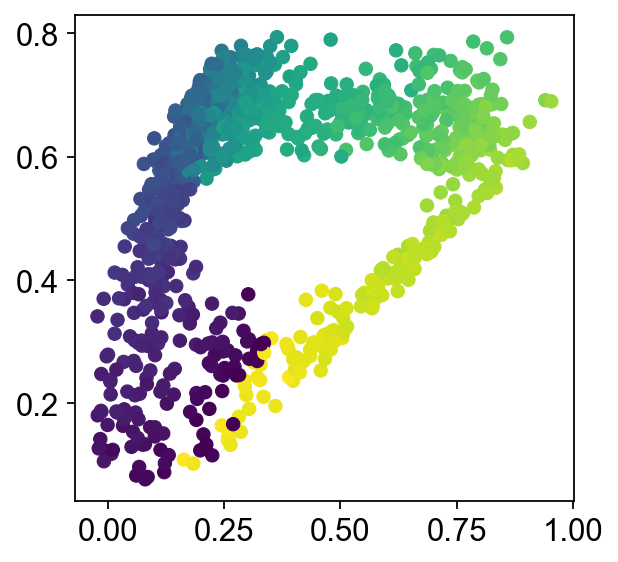

In [20]:
gene1 = 'KNSTRN'
gene2 = 'MELK'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.scatter(reconstruct[:, index1], reconstruct[:, index2],c=th,cmap=cm.viridis)

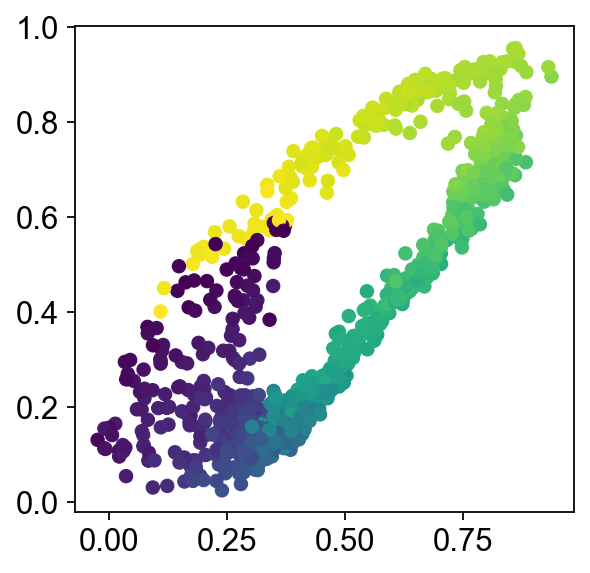

In [21]:
## Decoder构成了20维隐空间到任意两维基因空间的投影
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
weight_proj = weight[[index1,index2],:].T
np_data_gene = (latent @ weight_proj) + bias[[index1,index2]]
plt.scatter(np_data_gene[:, 0], np_data_gene[:, 1],c=th,cmap=cm.viridis)

In [22]:
## 计算velocity及jacobian
velocity = vf_func(latent_z)
jac_dyn = jac_func_dyn(latent_z)
jac_enc = jac_func_encoder(raw)
jac_dec = jac_func_decoder(latent)
jac_norm = np.diag(1/latent.std(0))
jac_norm_inv = np.diag(latent.std(0))

In [23]:
## 对隐空间坐标位移一个V的单位并重构
latent_plus = (latent_z + velocity) * latent.std(0) + latent.mean(0)
latent_plus = torch.as_tensor(latent_plus, dtype=torch.float32)
reconstruct_plus = decoder(latent_plus)
reconstruct_plus = reconstruct_plus.detach().numpy()
velocity_reconstruct2 = reconstruct_plus - reconstruct ## 重构的velocity

velocity_reconstruct = (velocity * latent.std(0)) @ (weight.T) ## 等价算法，会有数值误差 velocity @ (new_weight.T)

Text(0.5, 1.0, 'CCNA2_CCNB1')

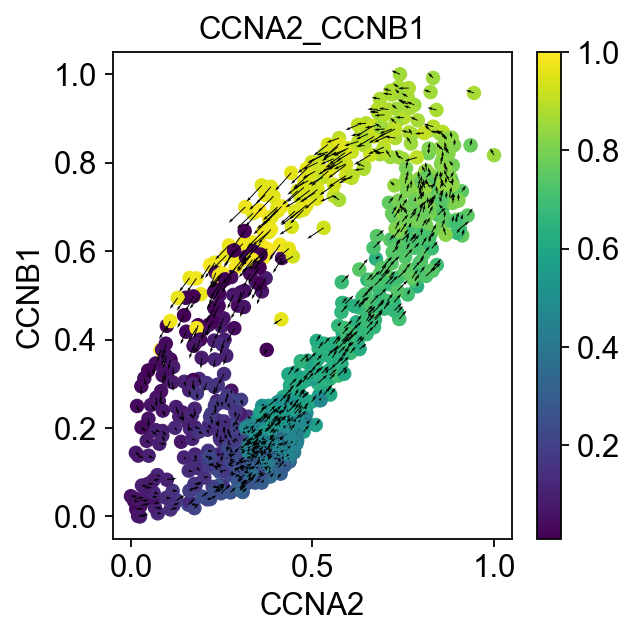

In [24]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.scatter(np_data[:, index1], np_data[:, index2],c=th,cmap=cm.viridis)
plt.quiver(np_data[:, index1], np_data[:, index2], velocity_reconstruct[:, index1], velocity_reconstruct[:, index2],scale=50, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(gene1)
plt.ylabel(gene2)
plt.title(gene1+'_'+gene2)
# plt.savefig('a.png', dpi=300)

Text(0.5, 1.0, 'CCNA2_CCNB1')

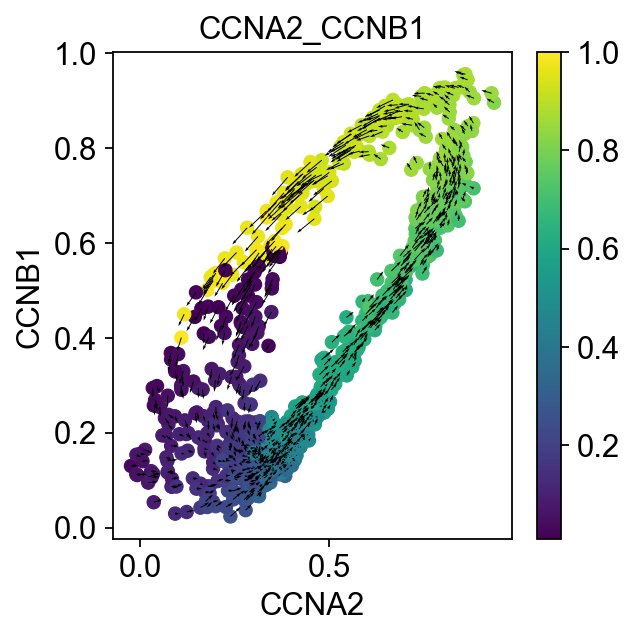

In [25]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.scatter(reconstruct[:, index1], reconstruct[:, index2],c=th,cmap=cm.viridis)
plt.quiver(reconstruct[:, index1], reconstruct[:, index2], velocity_reconstruct[:, index1], velocity_reconstruct[:, index2],scale=50, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(gene1)
plt.ylabel(gene2)
plt.title(gene1+'_'+gene2)

In [26]:
## 对标准化latent坐标PCA降维
pca = PCA(n_components=2)
pca.fit(latent_z)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
latent_z_pca = (latent_z - np.mean(latent_z, axis=0)) @ V

# 得到速率投影
v_pca = velocity @ V
v_norm = (v_pca.T/np.linalg.norm(v_pca, axis=1)).T

# 雅可比矩阵推断

In [27]:
## 得到每个细胞对应的F对每个基因的雅可比矩阵
n = latent_z.shape[0] # 细胞个数
jacobians_latent = np.zeros_like(jac_enc)
jacobians = np.zeros((1066, 1066, n)) # F的雅可比矩阵
divergence1 = np.zeros((n))
divergence2 = np.zeros((n))
for i in range(n):
    jac1 = jac_dyn[:,:,i]
    jac2 = jac_enc[:,:,i]
    jac3 = weight
    divergence1[i] = np.trace(jac1)
    jac_latent = jac1 @ jac_norm @ jac2 # 隐变量F对基因的雅可比
    jac = jac3 @ jac_norm_inv @ jac_latent # 重构F对基因的雅可比
    divergence2[i] = np.trace(jac)
    jacobians[:, :, i] = jac
    jacobians_latent[:, :, i] = jac_latent

In [28]:
## 考察每个phase的平均的雅可比阵
cell_cycle_phase = adata.obs['cell_cycle_phase']
jacobians_mean_by_phase = {}

for phase in cell_cycle_phase.cat.categories:
    indices = cell_cycle_phase == phase
    jacobians_mean_by_phase[phase] = np.mean(jacobians[:, :, indices], axis=-1)

In [29]:
## 考察平均的雅可比阵
jacobians_mean = np.mean(jacobians, axis=-1)
jacobians_mean

array([[-0.01701079,  0.0132332 ,  0.02132249, ..., -0.00540515,
         0.02340989,  0.07188832],
       [-0.1952523 ,  0.07317692, -0.02022244, ..., -0.11879793,
         0.01133991, -0.13895781],
       [-0.00874155, -0.04938921, -0.03088913, ..., -0.0531833 ,
        -0.03949445, -0.06982339],
       ...,
       [-0.07445415, -0.03414324, -0.01309099, ..., -0.11057952,
        -0.01691842, -0.11905747],
       [ 0.0213561 , -0.04865748,  0.01872649, ..., -0.01697486,
        -0.00294743, -0.03560074],
       [ 0.10243276, -0.14090201,  0.04560441, ..., -0.07109701,
         0.00796247, -0.00809273]])

In [30]:
## 计算out-edge eigenvector centrality基因排名的函数
def calculate_top_genes(jacobians, genes, threshold_percentile=90, max_iter=1000, tol=1e-6, gene_num=20):
    weight = np.abs(jacobians).T  # 这里需要转置
    threshold = np.percentile(weight, threshold_percentile)
    adjacency_matrix = np.where(weight >= threshold, weight, 0)
    sparse_matrix = csr_matrix(adjacency_matrix)
    G = nx.from_scipy_sparse_array(sparse_matrix, create_using=nx.DiGraph)
    out_edge_centrality = nx.eigenvector_centrality(G, weight='weight', max_iter=max_iter, tol=tol)
    # out_edge_centrality = nx.eigenvector_centrality_numpy(G, weight='weight')
    sorted_centrality = sorted(out_edge_centrality.items(), key=lambda x: x[1], reverse=True)
    indices = [x[0] for x in sorted_centrality[:gene_num]]
    top_genes = [genes[i] for i in indices]
    return top_genes

In [31]:
## 绘制GRN的函数
def plot_custom_graph(G, node_color='#EAE0D5', positive_color='#A3320B', negative_color='#61988E', f_color='black', edge_width=1,
                      ax_network=None,network_node_file=None,save_path=None, expression_array=None, node_order=None):
    if ax_network is None:
        fig, ax_network = plt.subplots(figsize=(8, 6))
    
    pos = nx.circular_layout(G)  # Initial position layout
    if network_node_file is not None:
        network_node = pd.read_csv(network_node_file, delimiter='\t', index_col=0)
        # Filter out nodes not present in the network_node file
        nodes_to_remove = [node for node in pos.keys() if node not in network_node.index]
        G.remove_nodes_from(nodes_to_remove)
        pos = {node: pos[node] for node in pos if node in network_node.index}
        print("The following genes are either not protein coding genes or not found in string-db: ", nodes_to_remove)
        for i in pos.keys():
            pos[i][0] = network_node.loc[i, 'x_position']
            pos[i][1] = 1 - network_node.loc[i, 'y_position']

    if expression_array is not None and node_order is not None:
        min_size, max_size = 200, 2200
        expr_min, expr_max = 0, 1
        sizes = []
        for node in G.nodes():
            if node in node_order:
                idx = node_order.index(node)
                val = expression_array[idx]
                # 线性归一化
                size = min_size + (val - expr_min) / (expr_max - expr_min) * (max_size - min_size)
                sizes.append(size)
            else:
                sizes.append(1000)  # 默认值
    else:
        sizes = 1500
            
    nx.draw_networkx_nodes(G, pos, ax=ax_network, node_color=node_color, node_size=sizes)
    nx.draw_networkx_labels(G, pos, ax=ax_network, font_family='Arial', font_size=23, font_color=f_color)

    for u, v, data in G.edges(data=True):
        if data['weight'] > 0:
            color = positive_color
            style = "->"
            size = 20
        else:
            color = negative_color
            style = "-["
            size = 6
        width = abs(data['weight']) * edge_width
        nx.draw_networkx_edges(G, pos, ax=ax_network, edgelist=[(u, v)], width=width, edge_color=color, 
                               arrows=True, arrowstyle=style, arrowsize=size, connectionstyle=f"arc3,rad={0.15}", node_size=2600)
        
    # Create custom legend
    legend_elements = [
        Line2D([0], [0], color=positive_color, lw=4, label='Positive'),
        Line2D([0], [0], color=negative_color, lw=4, label='Negative')
    ]
    ax_network.legend(handles=legend_elements, loc='best')

    ax_network.set_frame_on(False)
    
    # plt.title('Gene Regulatory Network')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', transparent=True)
        
    plt.show()

In [32]:
## 构建GRN
# 提取感兴趣的基因
# genes_interest = [
#     "CCND1", "CCND2", "CCND3",
#     "CDK4", "CDK6",
#     "CCNE1", "CCNE2",
#     "RB1",
#     "E2F1", "E2F2", "E2F3",
#     "CCNA2",
#     "CDK2","CDK1",
#     "CDH1","CDC20",
#     "CCNB1","CCNB2",
#     "WEE1",
#     "CDC25A", "CDC25B", "CDC25C",
#     "CDKN1A", "CDKN1B",
# ]
# genes_interest = calculate_top_genes(jacobians_mean, genes, gene_num=20)
genes_interest = ['MCM3',
 'FAM83D',
 'UBE2C',
 'FBXO5',
 'E2F4',
 'CCNF',
 'CDC6',
 'PSRC1',
 'TOP2A',
 'CDC25A',
 'NAA50', 
 'HSPA8',
 'DDX3X',
 'CNOT9',
 'FZR1',
 'CDK1',
 'BORA',
 'NSUN2',
 'CENPC',
 'CCNE1']
gi = [genes.index(gene) for gene in genes_interest if gene in genes]
g = [gene for gene in genes_interest if gene in genes]

heatmap_data = jacobians_mean[gi][:, gi]
expression_data = np_data[:,gi] # 提取这些基因表达
expression_mean_by_phase = {}
for phase in cell_cycle_phase.cat.categories:
    indices = cell_cycle_phase == phase
    expression_mean_by_phase[phase] = np.mean(expression_data[indices, :], axis=0)
genes_interest

['MCM3',
 'FAM83D',
 'UBE2C',
 'FBXO5',
 'E2F4',
 'CCNF',
 'CDC6',
 'PSRC1',
 'TOP2A',
 'CDC25A',
 'NAA50',
 'HSPA8',
 'DDX3X',
 'CNOT9',
 'FZR1',
 'CDK1',
 'BORA',
 'NSUN2',
 'CENPC',
 'CCNE1']

In [33]:
## 提取每个阶段的中心基因
gene_num=25
genes_interest_g1s = calculate_top_genes(jacobians_mean_by_phase['G1-S'], genes, gene_num=gene_num)
genes_interest_s = calculate_top_genes(jacobians_mean_by_phase['S'], genes, gene_num=gene_num)
genes_interest_g2m = calculate_top_genes(jacobians_mean_by_phase['G2-M'], genes, gene_num=gene_num)
genes_interest_m = calculate_top_genes(jacobians_mean_by_phase['M'], genes, gene_num=gene_num)
genes_interest_mg1 = calculate_top_genes(jacobians_mean_by_phase['M-G1'], genes, gene_num=gene_num)

from collections import Counter

# 5 个列表合并
all_genes = (
    genes_interest_g1s +
    genes_interest_s +
    genes_interest_g2m +
    genes_interest_m +
    genes_interest_mg1
)

# 统计每个基因出现次数
gene_counts = Counter(all_genes)

# 筛选至少出现两次的基因
genes_at_least_twice = [gene for gene, count in gene_counts.items() if count >= 2]

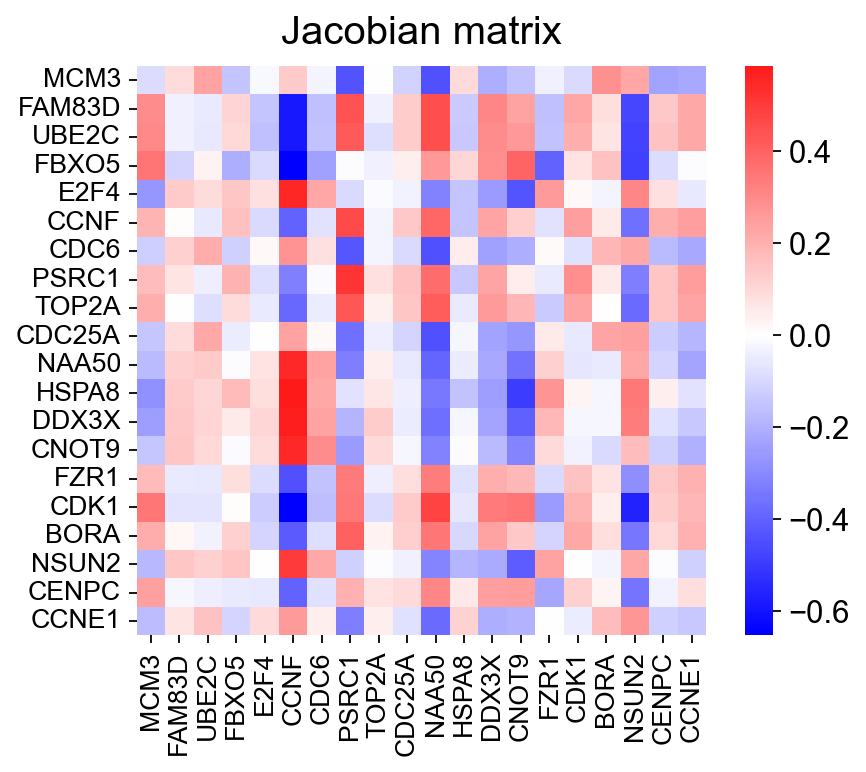

In [34]:
plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap=cmap, cbar=True, square=True,
            xticklabels=g, yticklabels=g, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(g, fontsize=12, rotation=90)
ax.set_yticklabels(g, fontsize=12, rotation=0)

plt.title("Jacobian matrix", fontsize=18, pad=10)

plt.tight_layout()
plt.savefig('figures/jacobians_mean.svg', bbox_inches='tight', transparent=True)
plt.show()

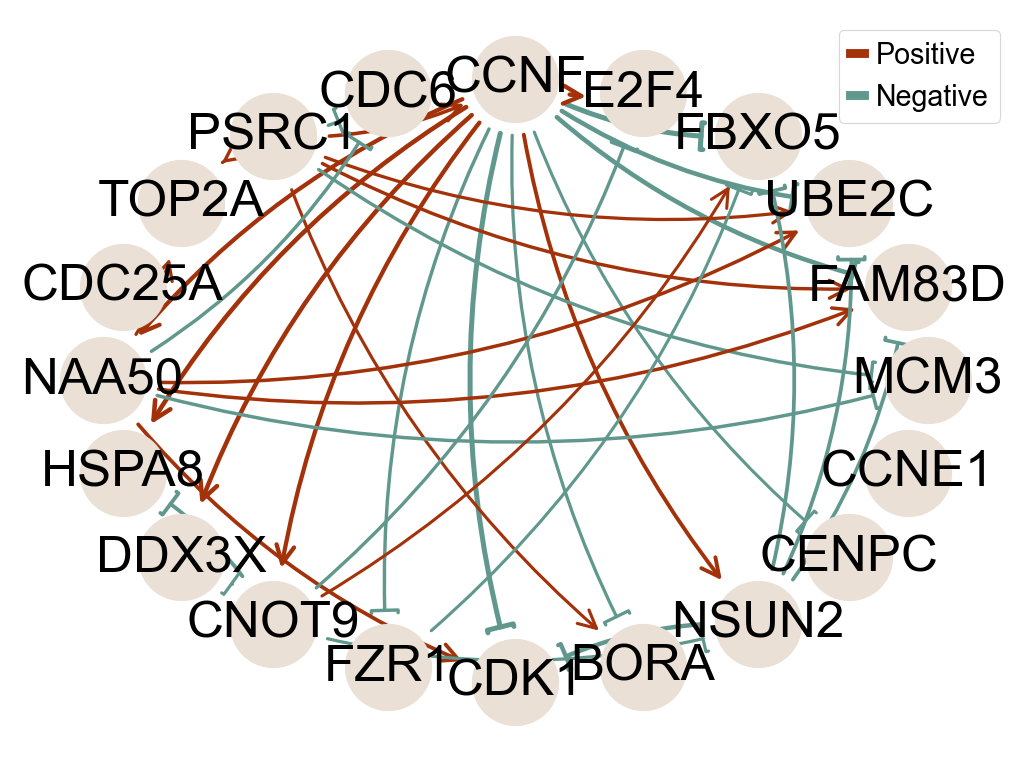

In [35]:
threshold_a = np.percentile(abs(heatmap_data), 90) # 设置阈值
significant_connections = np.where(abs(heatmap_data) > threshold_a)

G = nx.MultiDiGraph()
num_nodes = heatmap_data.shape[0]
for i in range(num_nodes):
    G.add_node(g[i])

for i, j in zip(significant_connections[0], significant_connections[1]):
    if i != j:
        weight = heatmap_data[i, j]
        G.add_edge(g[j], g[i], weight=weight, direction='forward')


plot_custom_graph(G, edge_width=3.5, save_path="figures/network_mean.svg")

# G1-S期

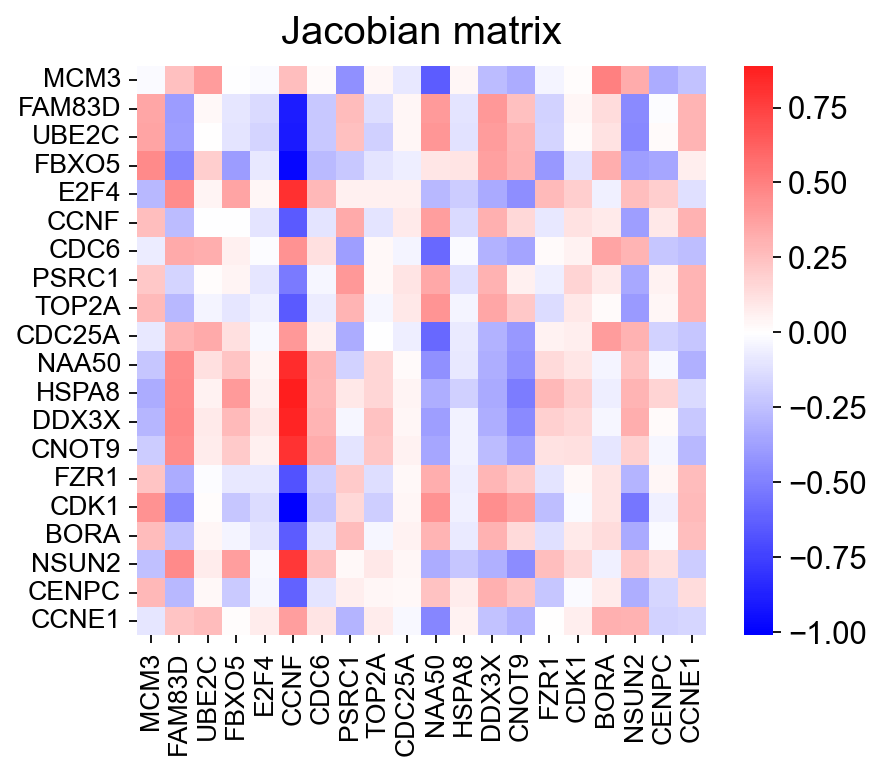

In [36]:
heatmap_data = jacobians_mean_by_phase['G1-S'][gi][:, gi]

plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap=cmap, cbar=True, square=True,
            xticklabels=g, yticklabels=g, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(g, fontsize=12, rotation=90)
ax.set_yticklabels(g, fontsize=12, rotation=0)

plt.title("Jacobian matrix", fontsize=18, pad=10)

plt.tight_layout()
plt.savefig('figures/jacobians_G1S.svg', bbox_inches='tight', transparent=True)
plt.show()

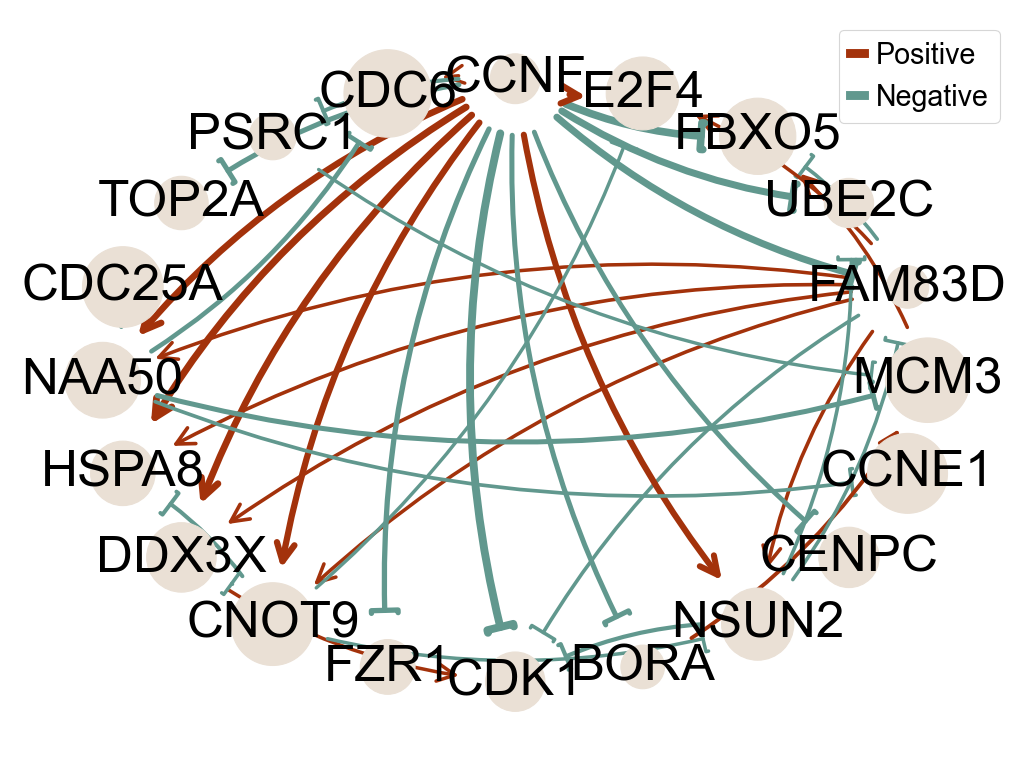

In [37]:
threshold_a = np.percentile(abs(heatmap_data), 90) # 设置阈值
significant_connections = np.where(abs(heatmap_data) > threshold_a)

G = nx.MultiDiGraph()
num_nodes = heatmap_data.shape[0]
for i in range(num_nodes):
    G.add_node(g[i])

for i, j in zip(significant_connections[0], significant_connections[1]):
    if i != j:
        weight = heatmap_data[i, j]
        G.add_edge(g[j], g[i], weight=weight, direction='forward')


plot_custom_graph(G, edge_width=3.5,expression_array=expression_mean_by_phase['G1-S'],node_order=genes_interest, save_path="figures/network_G1S.svg")

# S期

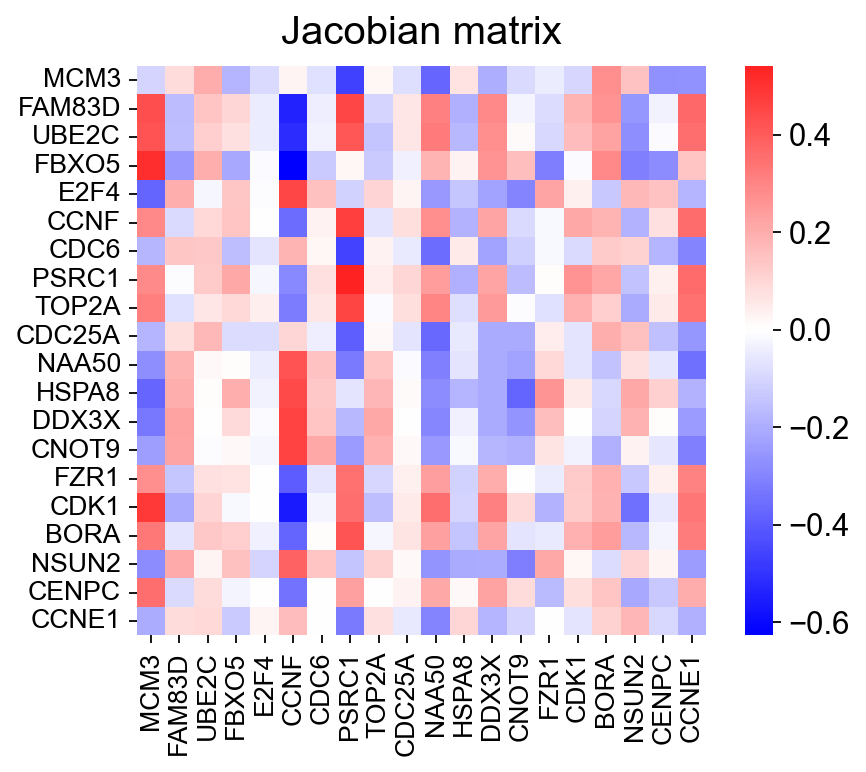

In [38]:
heatmap_data = jacobians_mean_by_phase['S'][gi][:, gi]

plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap=cmap, cbar=True, square=True,
            xticklabels=g, yticklabels=g, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(g, fontsize=12, rotation=90)
ax.set_yticklabels(g, fontsize=12, rotation=0)

plt.title("Jacobian matrix", fontsize=18, pad=10)

plt.tight_layout()
plt.savefig('figures/jacobians_S.svg', bbox_inches='tight', transparent=True)
plt.show()

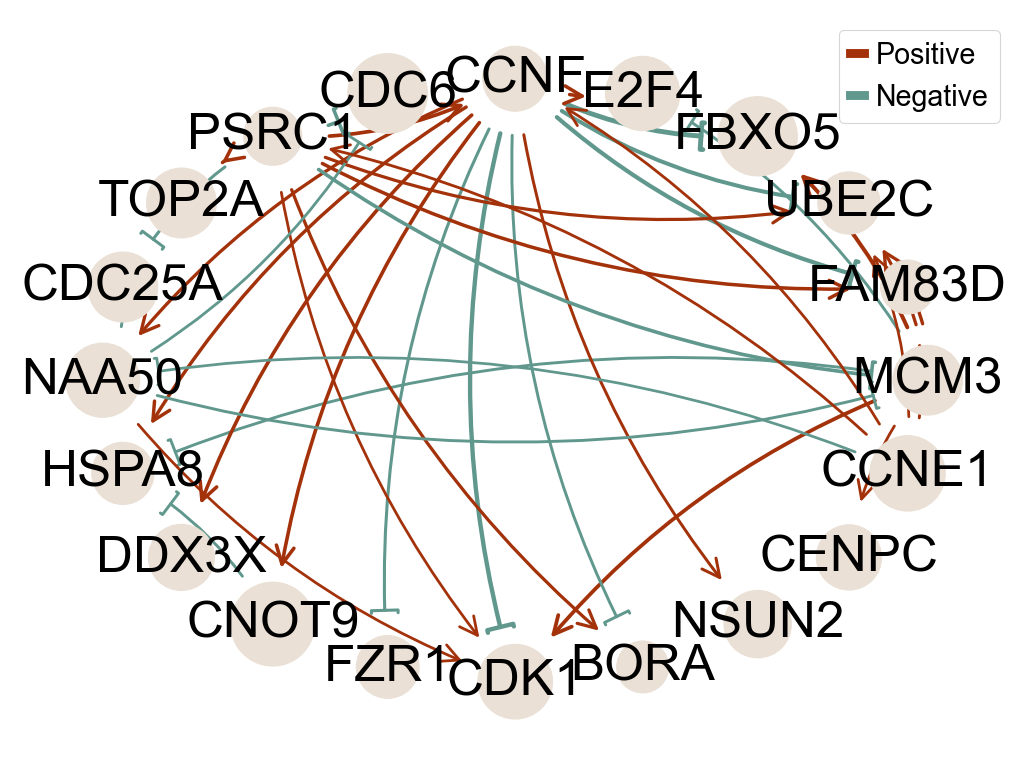

In [39]:
threshold_a = np.percentile(abs(heatmap_data), 90) # 设置阈值
significant_connections = np.where(abs(heatmap_data) > threshold_a)

G = nx.MultiDiGraph()
num_nodes = heatmap_data.shape[0]
for i in range(num_nodes):
    G.add_node(g[i])

for i, j in zip(significant_connections[0], significant_connections[1]):
    if i != j:
        weight = heatmap_data[i, j]
        G.add_edge(g[j], g[i], weight=weight, direction='forward')


plot_custom_graph(G, edge_width=3.5,expression_array=expression_mean_by_phase['S'],node_order=genes_interest, save_path="figures/network_S.svg")

# G2-M期

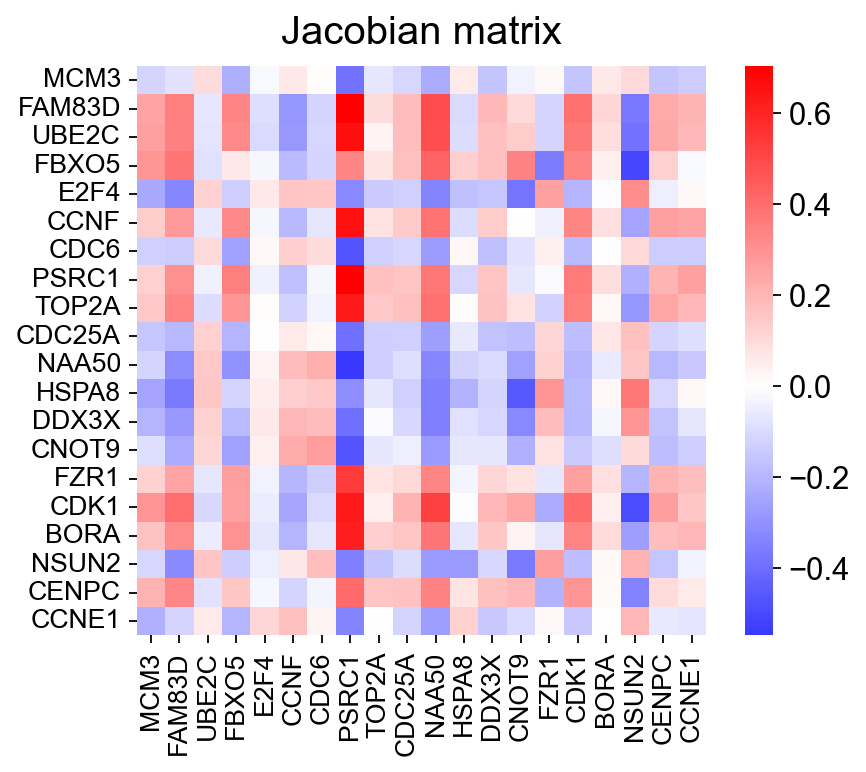

In [40]:
heatmap_data = jacobians_mean_by_phase['G2-M'][gi][:, gi]

plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap=cmap, cbar=True, square=True,
            xticklabels=g, yticklabels=g, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(g, fontsize=12, rotation=90)
ax.set_yticklabels(g, fontsize=12, rotation=0)

plt.title("Jacobian matrix", fontsize=18, pad=10)

plt.tight_layout()
plt.savefig('figures/jacobians_G2M.svg', bbox_inches='tight', transparent=True)
plt.show()

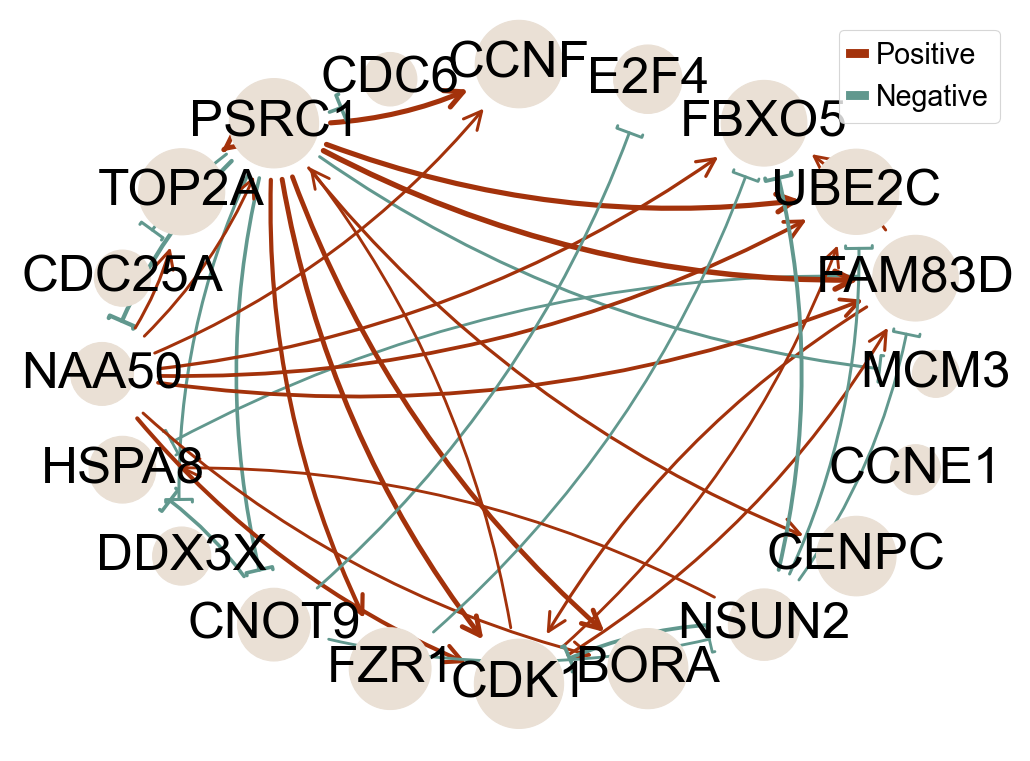

In [41]:
threshold_a = np.percentile(abs(heatmap_data), 90) # 设置阈值
significant_connections = np.where(abs(heatmap_data) > threshold_a)

G = nx.MultiDiGraph()
num_nodes = heatmap_data.shape[0]
for i in range(num_nodes):
    G.add_node(g[i])

for i, j in zip(significant_connections[0], significant_connections[1]):
    if i != j:
        weight = heatmap_data[i, j]
        G.add_edge(g[j], g[i], weight=weight, direction='forward')


plot_custom_graph(G, edge_width=3.5,expression_array=expression_mean_by_phase['G2-M'],node_order=genes_interest, save_path="figures/network_G2M.svg")

# M期

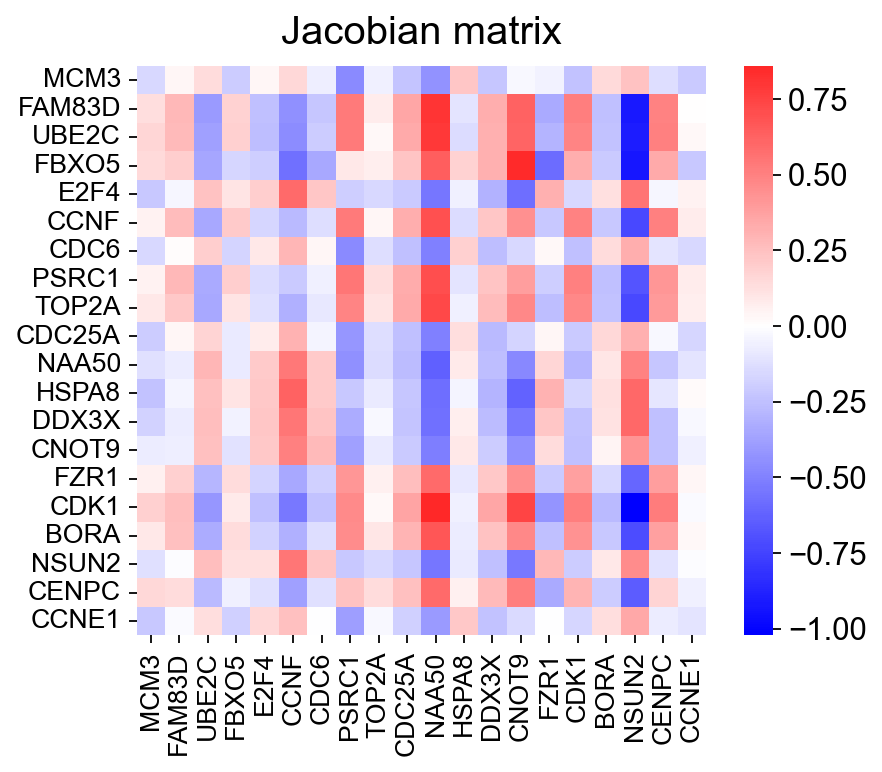

In [42]:
heatmap_data = jacobians_mean_by_phase['M'][gi][:, gi]

plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap=cmap, cbar=True, square=True,
            xticklabels=g, yticklabels=g, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(g, fontsize=12, rotation=90)
ax.set_yticklabels(g, fontsize=12, rotation=0)

plt.title("Jacobian matrix", fontsize=18, pad=10)

plt.tight_layout()
plt.savefig('figures/jacobians_M.svg', bbox_inches='tight', transparent=True)
plt.show()

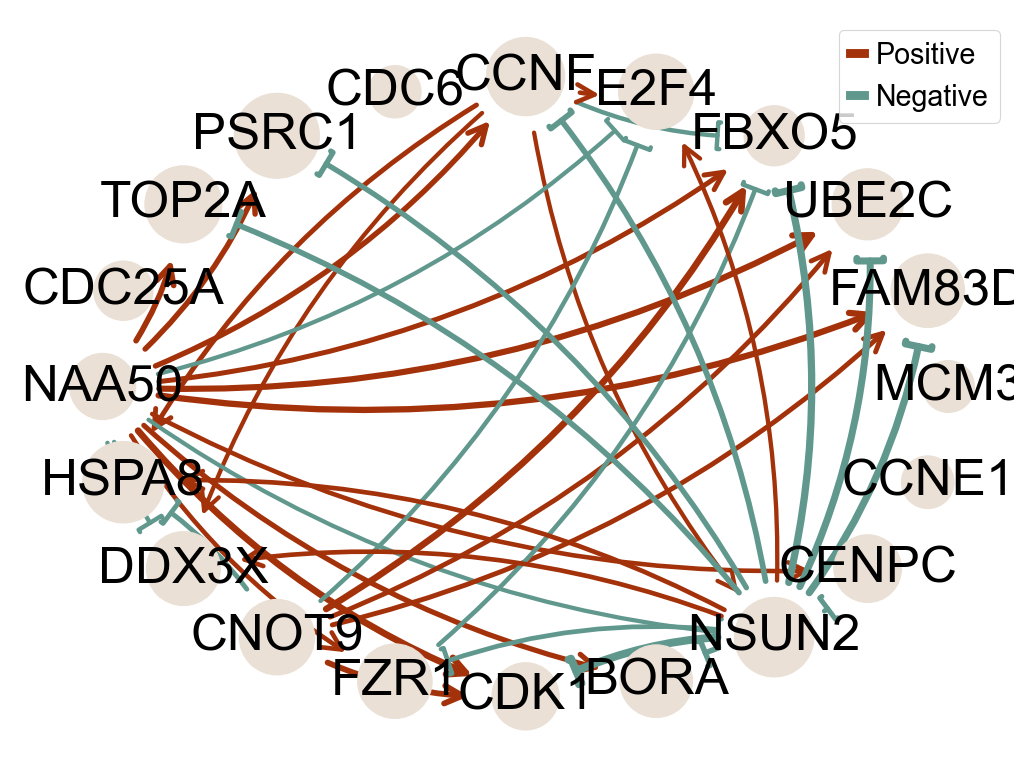

In [43]:
threshold_a = np.percentile(abs(heatmap_data), 90) # 设置阈值
significant_connections = np.where(abs(heatmap_data) > threshold_a)

G = nx.MultiDiGraph()
num_nodes = heatmap_data.shape[0]
for i in range(num_nodes):
    G.add_node(g[i])

for i, j in zip(significant_connections[0], significant_connections[1]):
    if i != j:
        weight = heatmap_data[i, j]
        G.add_edge(g[j], g[i], weight=weight, direction='forward')


plot_custom_graph(G, edge_width=3.5,expression_array=expression_mean_by_phase['M'],node_order=genes_interest, save_path="figures/network_M.svg")

# M-G1期

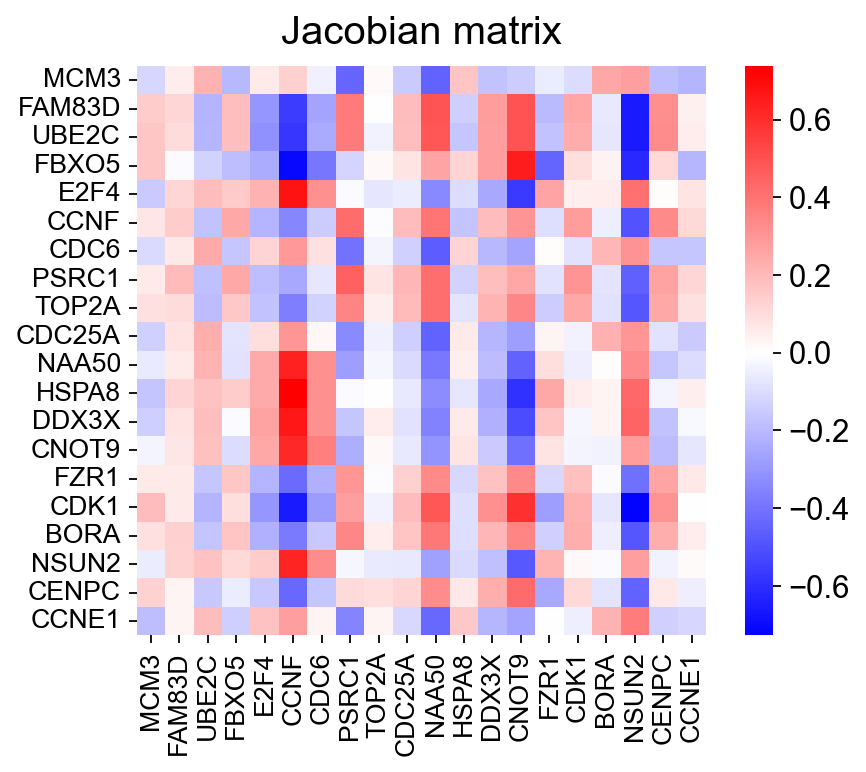

In [44]:
heatmap_data = jacobians_mean_by_phase['M-G1'][gi][:, gi]

plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap=cmap, cbar=True, square=True,
            xticklabels=g, yticklabels=g, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(g, fontsize=12, rotation=90)
ax.set_yticklabels(g, fontsize=12, rotation=0)

plt.title("Jacobian matrix", fontsize=18, pad=10)

plt.tight_layout()
plt.savefig('figures/jacobians_MG1.svg', bbox_inches='tight', transparent=True)
plt.show()

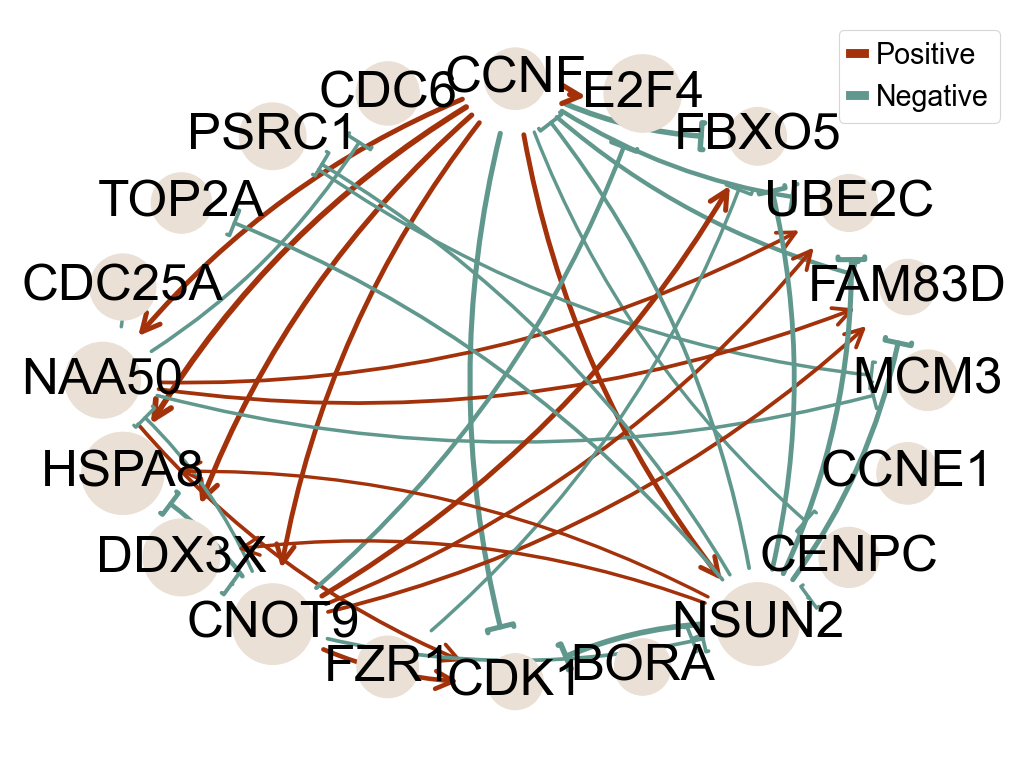

In [45]:
threshold_a = np.percentile(abs(heatmap_data), 90) # 设置阈值
significant_connections = np.where(abs(heatmap_data) > threshold_a)

G = nx.MultiDiGraph()
num_nodes = heatmap_data.shape[0]
for i in range(num_nodes):
    G.add_node(g[i])

for i, j in zip(significant_connections[0], significant_connections[1]):
    if i != j:
        weight = heatmap_data[i, j]
        G.add_edge(g[j], g[i], weight=weight, direction='forward')


plot_custom_graph(G, edge_width=3.5,expression_array=expression_mean_by_phase['M-G1'],node_order=genes_interest, save_path="figures/network_MG1.svg")

# 按雅可比矩阵着色

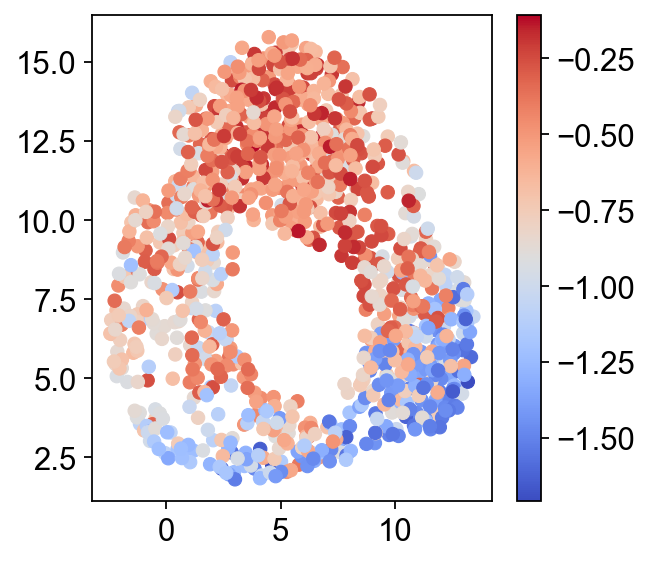

In [46]:
## 以雅可比元素着色
plt.scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],c=jacobians[155,118,:],cmap=cm.coolwarm)
plt.colorbar()

Text(0.5, 1.0, 'CCNA2_CCNB1')

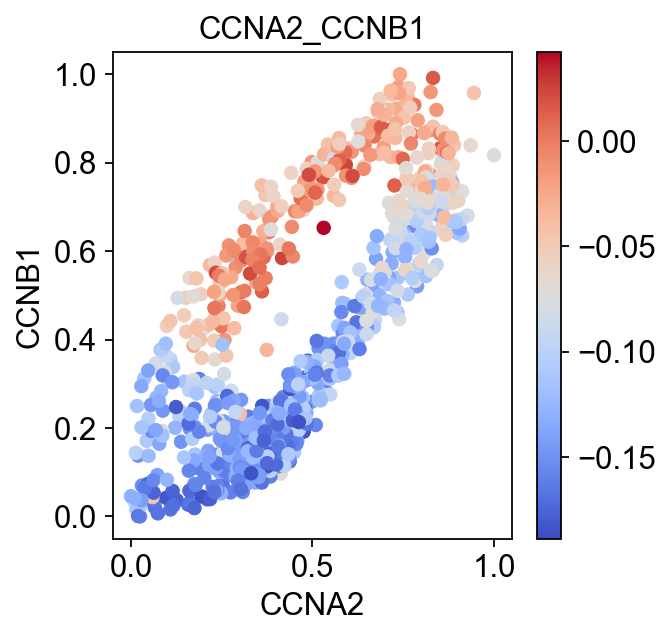

In [47]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.scatter(np_data[:, index1], np_data[:, index2],c=jacobians[index2,index2,:],cmap=cm.coolwarm)
plt.colorbar()
plt.xlabel(gene1)
plt.ylabel(gene2)
plt.title(gene1+'_'+gene2)